# GCSE English and A-level English Literature — a multilevel Bayesian model

The same question as the Maths notebook, for English: how does a school's value added at GCSE English (`P8MEAENG`, the English element of Progress 8) relate to its value added in A-level English Literature?

We use the errors-in-variables regression from `a-level-gcse.ipynb` — each school's *true* GCSE and A-level VA are latent, and the published confidence intervals give the known measurement noise — and fit it as a **multilevel model** where the intercept and slope vary by region with partial pooling. We compare it with the same model without a region level.

In [1]:
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm

%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v6.3.1


## Data

From `all-value-add-errors.csv` we take A-level English Literature VA with its confidence interval and entries, GCSE English VA (`P8MEAENG`) with its confidence interval, the Progress 8 cohort size (`P8 pupils`), and region. Schools need both VA scores. The standard error is `(upper - lower) / (2 * 1.96)`.

In [2]:
raw = pd.read_csv("data/all-value-add-errors.csv")

df = (
    raw[[
        "URN",
        "A-level English Literature VA", "A-level English Literature VA lower",
        "A-level English Literature VA upper", "A-level English Literature entries",
        "P8MEAENG", "P8MEAENG lower", "P8MEAENG upper", "P8 pupils", "RGN24NM",
    ]]
    .rename(columns={
        "A-level English Literature VA": "alevel_va",
        "A-level English Literature VA lower": "alevel_lower",
        "A-level English Literature VA upper": "alevel_upper",
        "A-level English Literature entries": "alevel_entries",
        "P8MEAENG": "gcse_va",
        "P8MEAENG lower": "gcse_lower",
        "P8MEAENG upper": "gcse_upper",
        "P8 pupils": "p8_pupils",
        "RGN24NM": "region",
    })
    .dropna(subset=["alevel_va", "gcse_va", "region"])
    .reset_index(drop=True)
)

Z_95 = 1.96
df["alevel_se"] = (df["alevel_upper"] - df["alevel_lower"]) / (2 * Z_95)
df["gcse_se"] = (df["gcse_upper"] - df["gcse_lower"]) / (2 * Z_95)

print(f"{len(df)} schools with both GCSE English and A-level English Literature value-added")
df[["alevel_va", "alevel_se", "gcse_va", "gcse_se", "alevel_entries", "p8_pupils"]].describe()

1284 schools with both GCSE English and A-level English Literature value-added


,alevel_va,alevel_se,gcse_va,gcse_se,alevel_entries,p8_pupils
count,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000
mean,-0.036628,0.263572,0.167072,0.118531,15.334891,198.483645
std,0.408656,0.064630,0.499894,0.019868,9.003333,56.603850
min,-1.670000,0.096939,-3.380000,0.076531,6.000000,22.000000
25%,-0.302500,0.214286,-0.140000,0.104592,9.000000,160.000000
50%,-0.020000,0.260204,0.160000,0.114796,13.000000,195.000000
75%,0.250000,0.311224,0.480000,0.127551,19.000000,233.000000
max,1.160000,0.382653,2.060000,0.344388,91.000000,444.000000


### Checking the confidence-interval formula

DfE's interval is $\pm 1.96\,\sigma_{national}/\sqrt{n}$, so $se_i\sqrt{n_i}$ should be constant across schools.

In [3]:
print("Implied national SD, A-level English Literature:")
print((df["alevel_se"] * np.sqrt(df["alevel_entries"])).agg(["mean", "std"]).round(3).to_dict())
print("Implied national SD, GCSE English (P8MEAENG):")
print((df["gcse_se"] * np.sqrt(df["p8_pupils"])).agg(["mean", "std"]).round(3).to_dict())

Implied national SD, A-level English Literature:
{'mean': 0.932, 'std': 0.004}
Implied national SD, GCSE English (P8MEAENG):
{'mean': 1.614, 'std': 0.015}


The implied SD is essentially constant, so `alevel_se` and `gcse_se` are pure sampling noise, as in the Maths analysis.

## Exploratory look

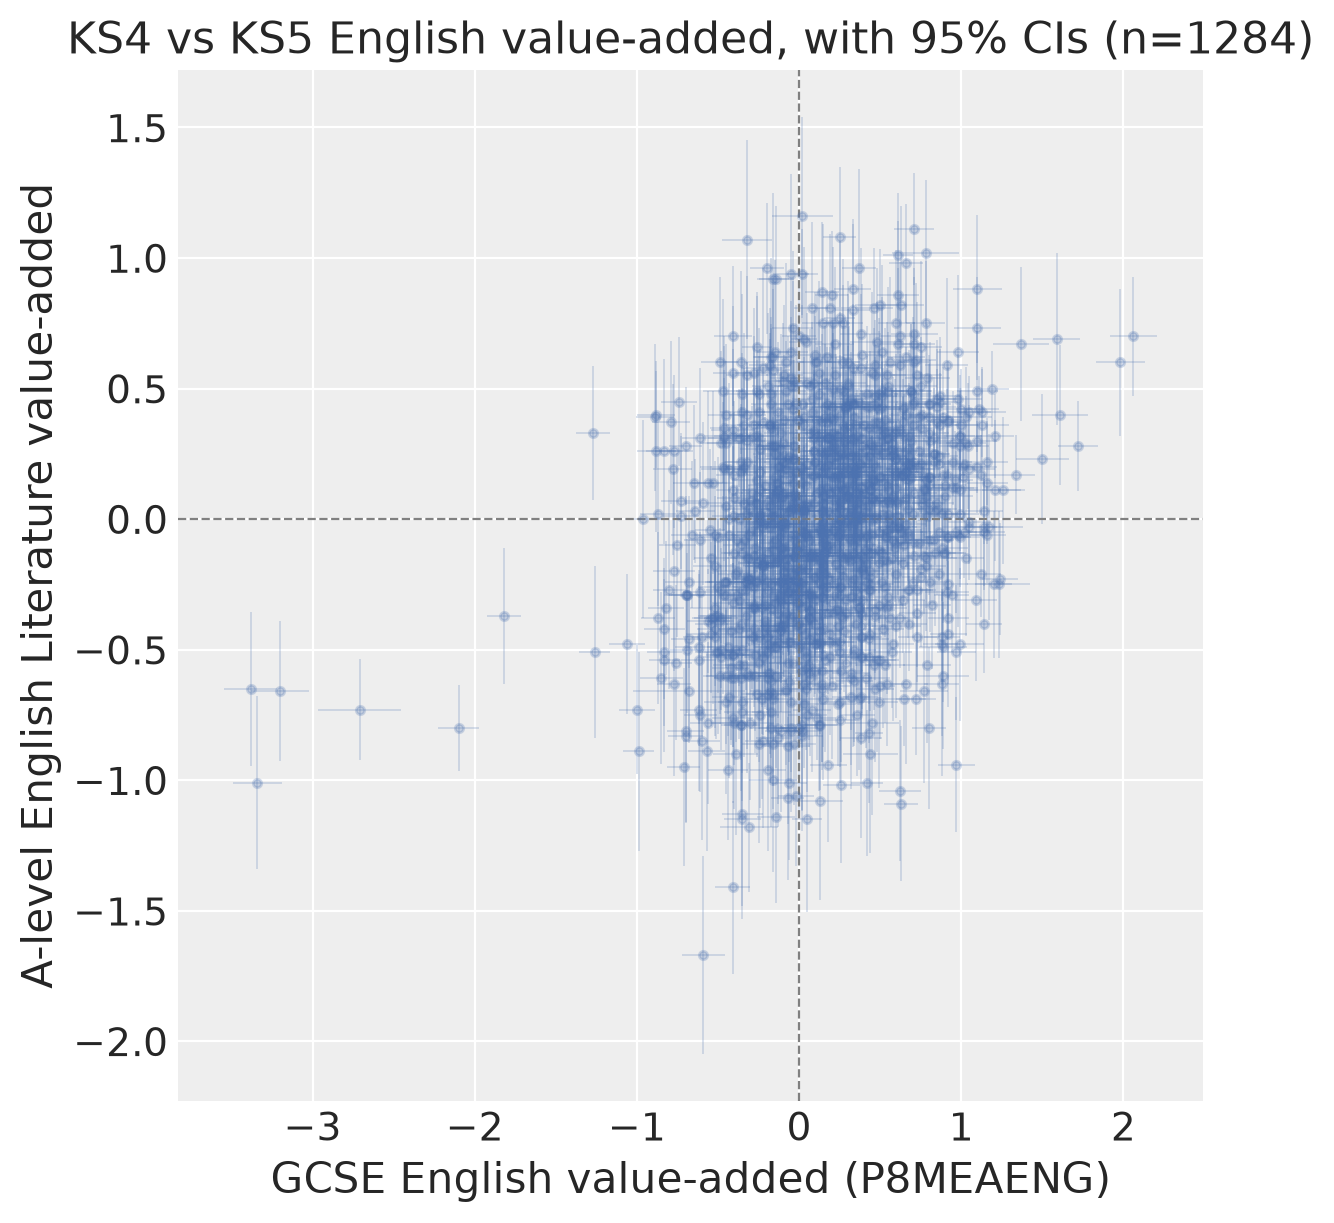

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(
    df["gcse_va"], df["alevel_va"], xerr=df["gcse_se"], yerr=df["alevel_se"],
    fmt="o", color="#4C72B0", ecolor="#4C72B0", alpha=0.25, markersize=3, elinewidth=0.6,
)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("GCSE English value-added (P8MEAENG)")
ax.set_ylabel("A-level English Literature value-added")
ax.set_title(f"KS4 vs KS5 English value-added, with 95% CIs (n={len(df)})")
plt.show()

## Models

Let $x_i$ and $y_i$ be school $i$'s true GCSE and A-level VA, observed with known standard errors. The base model has a single line; the multilevel model lets the line vary by region $r(i)$, drawing each region's intercept and slope from a population distribution:

$$
\begin{aligned}
x_i &\sim \text{Normal}(\mu_x, \tau_x), \qquad x_i^{obs} \sim \text{Normal}(x_i, \sigma^x_i) \\
\alpha_r &\sim \text{Normal}(\mu_\alpha, \sigma_\alpha), \quad \beta_r \sim \text{Normal}(\mu_\beta, \sigma_\beta) \\
y_i &= \alpha_{r(i)} + \beta_{r(i)} x_i + \epsilon_i, \quad \epsilon_i \sim \text{Normal}(0, \tau_y), \qquad y_i^{obs} \sim \text{Normal}(y_i, \sigma^y_i)
\end{aligned}
$$

Everything is non-centered. With only 9 regions, $\sigma_\alpha$ and $\sigma_\beta$ get a tighter `HalfNormal(0.5)` prior.

In [5]:
gcse_obs = df["gcse_va"].to_numpy()
gcse_se = df["gcse_se"].to_numpy()
alevel_obs = df["alevel_va"].to_numpy()
alevel_se = df["alevel_se"].to_numpy()
n_schools = len(df)

region_idx, region_labels = pd.factorize(df["region"])
print(df["region"].value_counts())

with pm.Model() as base_model:
    mu_x = pm.Normal("mu_x", mu=0, sigma=1)
    tau_x = pm.HalfNormal("tau_x", sigma=1)
    x_raw = pm.Normal("x_raw", mu=0, sigma=1, shape=n_schools)
    x_true = pm.Deterministic("x_true", mu_x + tau_x * x_raw)

    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1)
    tau_y = pm.HalfNormal("tau_y", sigma=1)
    y_raw = pm.Normal("y_raw", mu=0, sigma=1, shape=n_schools)
    y_true = pm.Deterministic("y_true", alpha + beta * x_true + tau_y * y_raw)

    pm.Normal("gcse_obs", mu=x_true, sigma=gcse_se, observed=gcse_obs)
    pm.Normal("alevel_obs", mu=y_true, sigma=alevel_se, observed=alevel_obs)

with pm.Model(coords={"region": region_labels}) as region_model:
    mu_x = pm.Normal("mu_x", mu=0, sigma=1)
    tau_x = pm.HalfNormal("tau_x", sigma=1)
    x_raw = pm.Normal("x_raw", mu=0, sigma=1, shape=n_schools)
    x_true = pm.Deterministic("x_true", mu_x + tau_x * x_raw)

    mu_alpha = pm.Normal("mu_alpha", mu=0, sigma=1)
    sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=0.5)
    alpha_raw = pm.Normal("alpha_raw", mu=0, sigma=1, dims="region")
    alpha_region = pm.Deterministic("alpha_region", mu_alpha + sigma_alpha * alpha_raw, dims="region")

    mu_beta = pm.Normal("mu_beta", mu=0, sigma=1)
    sigma_beta = pm.HalfNormal("sigma_beta", sigma=0.5)
    beta_raw = pm.Normal("beta_raw", mu=0, sigma=1, dims="region")
    beta_region = pm.Deterministic("beta_region", mu_beta + sigma_beta * beta_raw, dims="region")

    tau_y = pm.HalfNormal("tau_y", sigma=1)
    y_raw = pm.Normal("y_raw", mu=0, sigma=1, shape=n_schools)
    y_true = pm.Deterministic(
        "y_true", alpha_region[region_idx] + beta_region[region_idx] * x_true + tau_y * y_raw
    )

    pm.Normal("gcse_obs", mu=x_true, sigma=gcse_se, observed=gcse_obs)
    pm.Normal("alevel_obs", mu=y_true, sigma=alevel_se, observed=alevel_obs)

region
London                      304
South East                  215
East of England             163
West Midlands               143
South West                  123
East Midlands               111
North West                   98
Yorkshire and The Humber     79
North East                   48
Name: count, dtype: int64


### Prior predictive check

Sampling: [alevel_obs, alpha_raw, beta_raw, gcse_obs, mu_alpha, mu_beta, mu_x, sigma_alpha, sigma_beta, tau_x, tau_y, x_raw, y_raw]


/tmp/ipykernel_70788/2339752590.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


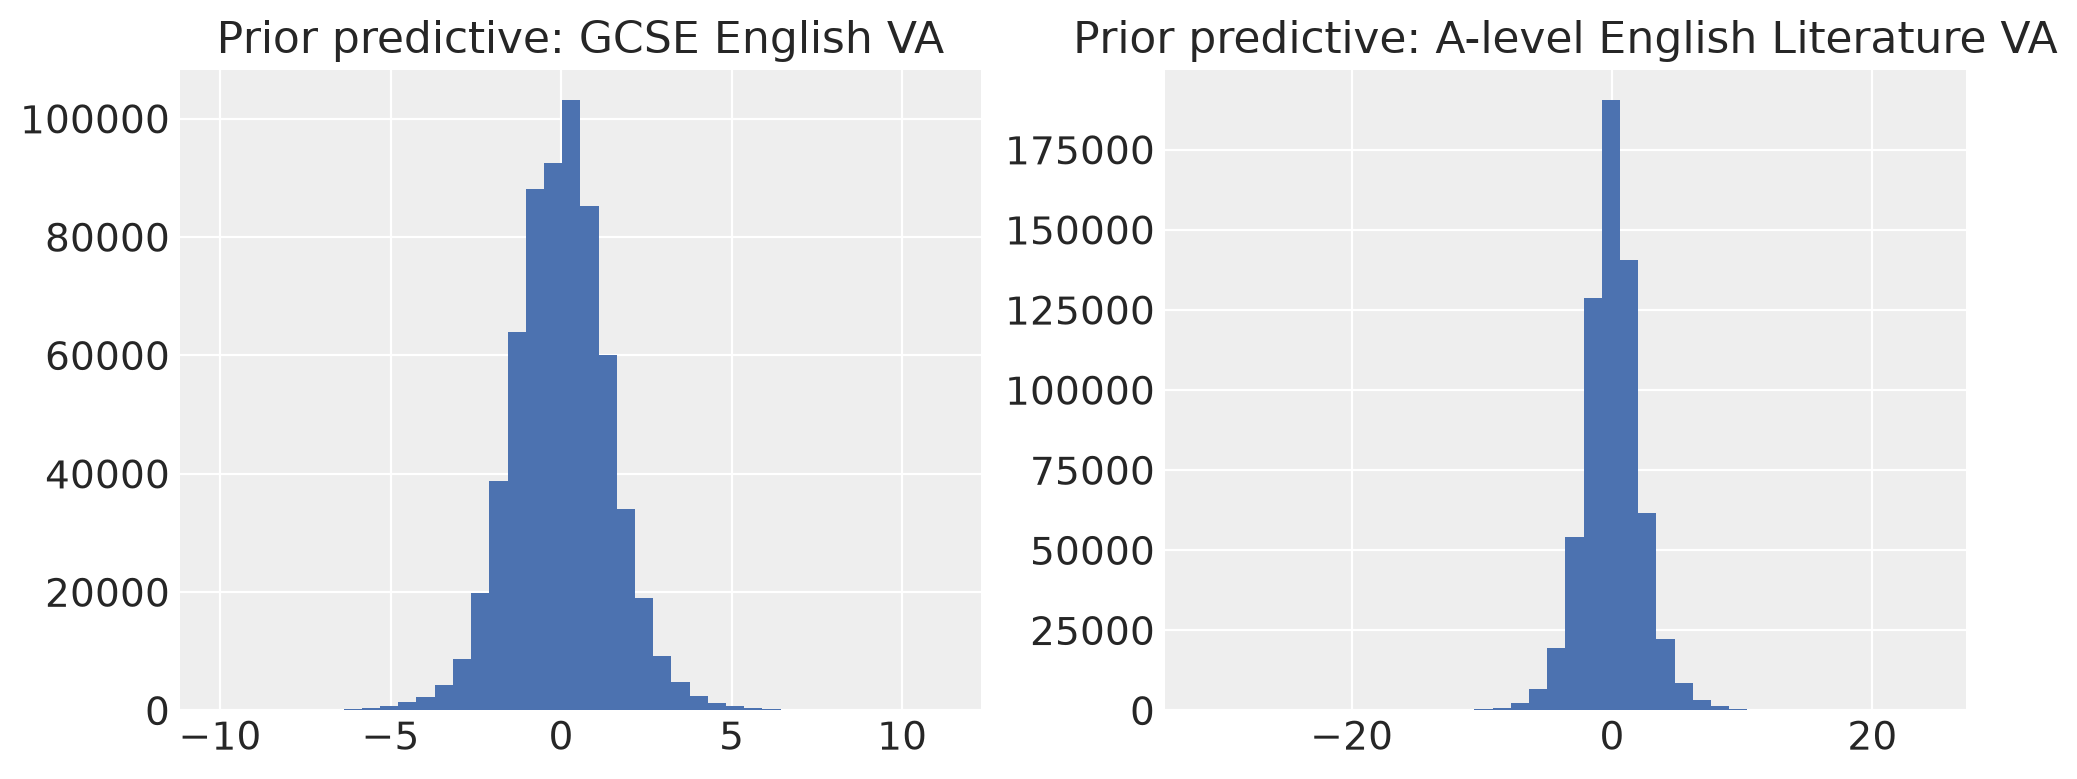

In [6]:
with region_model:
    prior = pm.sample_prior_predictive(draws=500, random_seed=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(prior.prior_predictive["gcse_obs"].to_numpy().ravel(), bins=40, color="#4C72B0")
axes[0].set_title("Prior predictive: GCSE English VA")
axes[1].hist(prior.prior_predictive["alevel_obs"].to_numpy().ravel(), bins=40, color="#4C72B0")
axes[1].set_title("Prior predictive: A-level English Literature VA")
plt.tight_layout()
plt.show()

### Fit

In [7]:
sample_kwargs = dict(draws=1000, tune=2000, chains=4, target_accept=0.99, random_seed=RANDOM_SEED)

with base_model:
    idata_base = pm.sample(**sample_kwargs)
    idata_base.update(pm.sample_posterior_predictive(idata_base, random_seed=RANDOM_SEED))

with region_model:
    idata_region = pm.sample(**sample_kwargs)
    idata_region.update(pm.sample_posterior_predictive(idata_region, random_seed=RANDOM_SEED))

NUTS[nutpie]: [mu_x, tau_x, x_raw, alpha, beta, tau_y, y_raw]


Output()

Sampling: [alevel_obs, gcse_obs]


Output()

NUTS[nutpie]: [mu_x, tau_x, x_raw, mu_alpha, sigma_alpha, alpha_raw, mu_beta, sigma_beta, beta_raw, tau_y, y_raw]


Output()

Sampling: [alevel_obs, gcse_obs]


Output()

### Diagnostics

In [8]:
for name, idt in [("base", idata_base), ("region", idata_region)]:
    print(f"{name}: divergences = {int(idt.sample_stats['diverging'].sum())}")

az.summary(idata_base, var_names=["alpha", "beta", "tau_y", "tau_x"], round_to=3)

base: divergences = 0
region: divergences = 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,-0.074,0.011,-0.092,-0.056,1476.471,2166.306,1.002,0.000,0.0
beta,0.254,0.022,0.219,0.289,1192.504,1740.576,1.003,0.001,0.0
tau_y,0.268,0.010,0.252,0.285,1459.113,1945.226,1.002,0.000,0.0
tau_x,0.479,0.010,0.463,0.496,337.764,488.502,1.009,0.001,0.0


In [9]:
az.summary(idata_region, var_names=["mu_alpha", "sigma_alpha", "mu_beta", "sigma_beta", "tau_y", "tau_x"], round_to=3)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_alpha,-0.078,0.021,-0.112,-0.046,636.430,864.686,1.004,0.001,0.001
sigma_alpha,0.048,0.024,0.015,0.088,357.186,460.951,1.014,0.001,0.001
mu_beta,0.246,0.029,0.200,0.291,1115.937,1599.605,1.005,0.001,0.001
sigma_beta,0.034,0.026,0.004,0.082,692.030,896.125,1.002,0.001,0.001
tau_y,0.266,0.010,0.250,0.282,1467.265,2220.209,1.003,0.000,0.000
tau_x,0.479,0.010,0.463,0.495,469.178,754.405,1.003,0.000,0.000


## Region-level intercepts and slopes

Each region's estimate is shrunk toward the population mean by partial pooling.

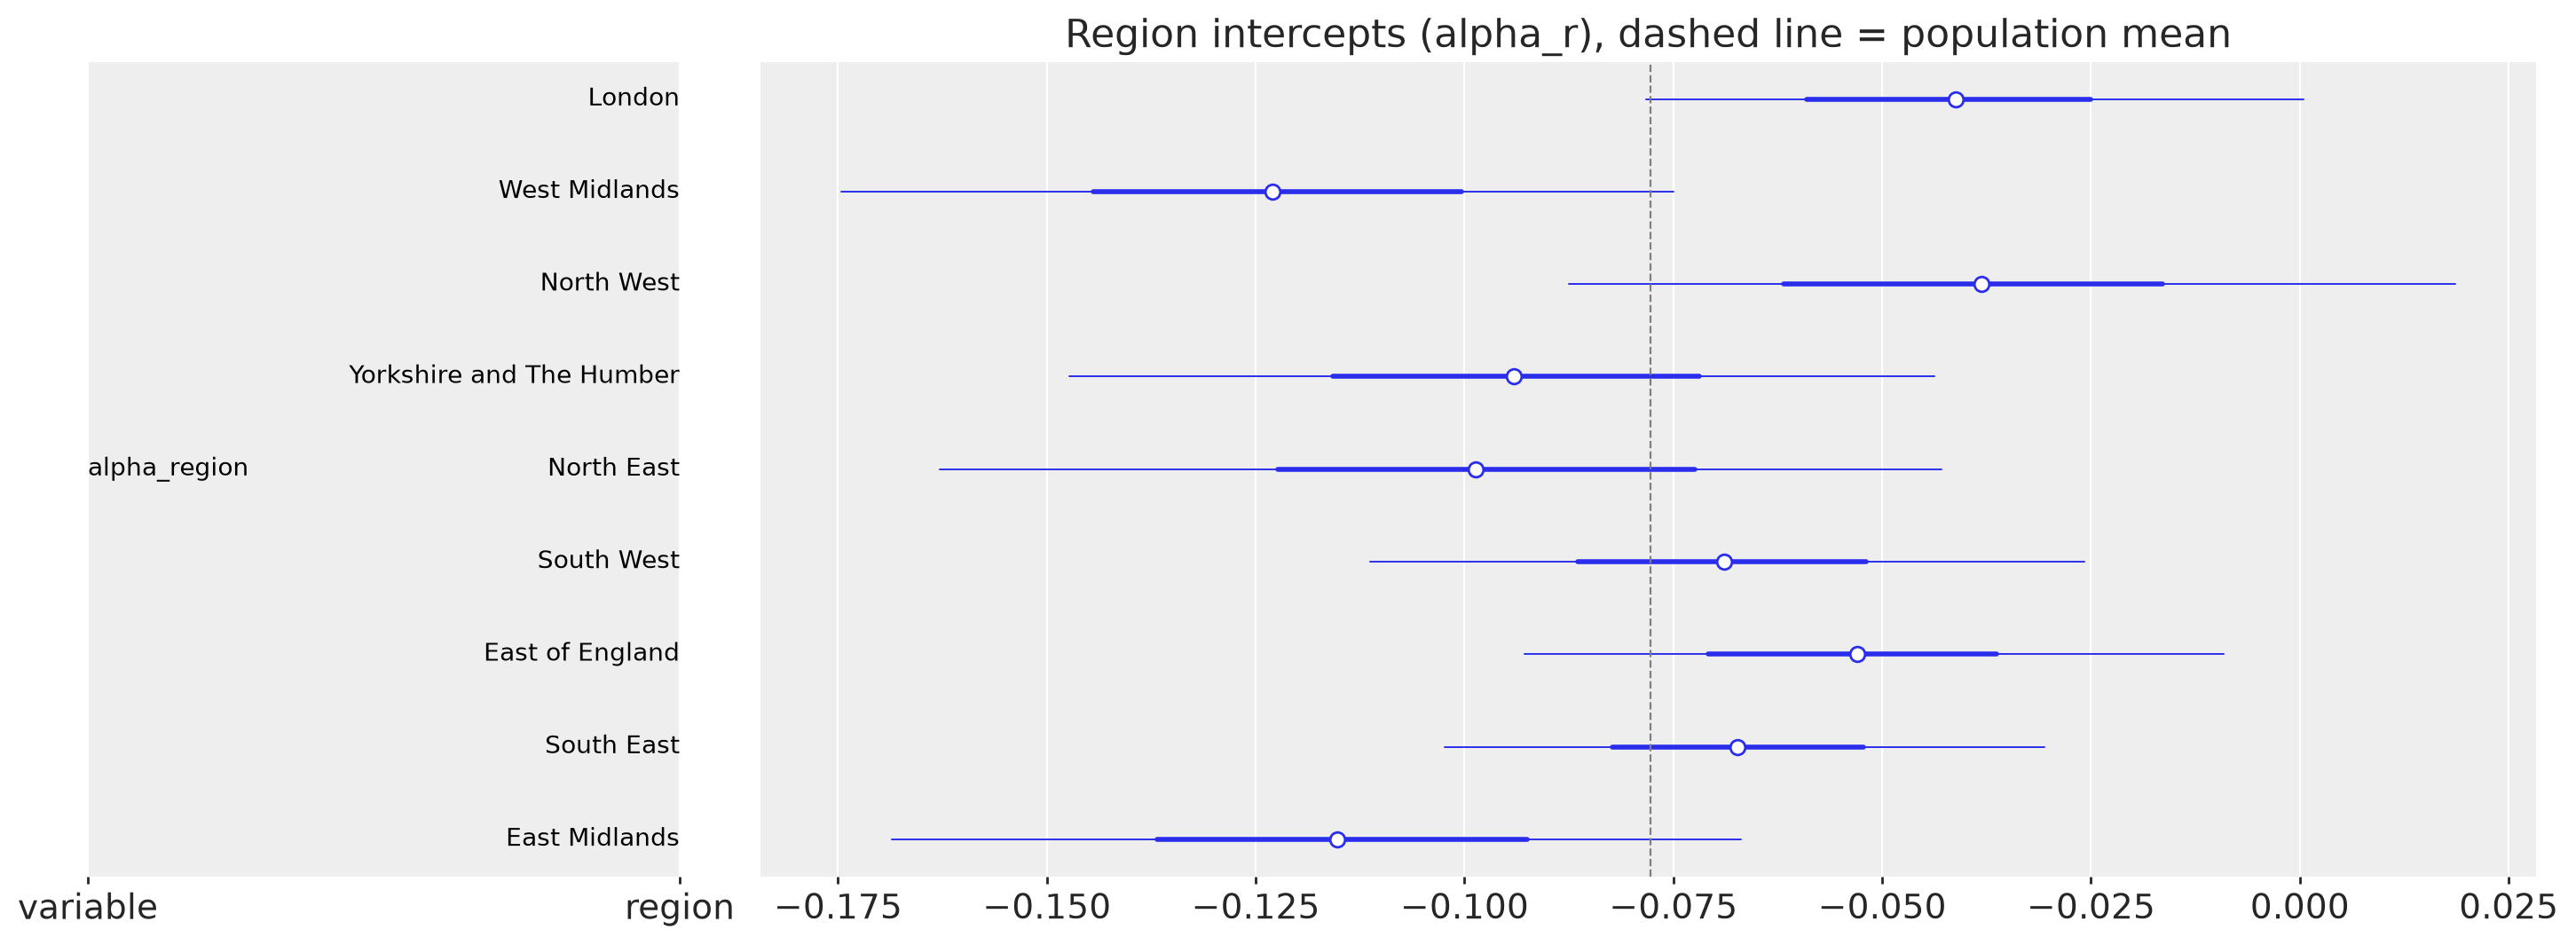

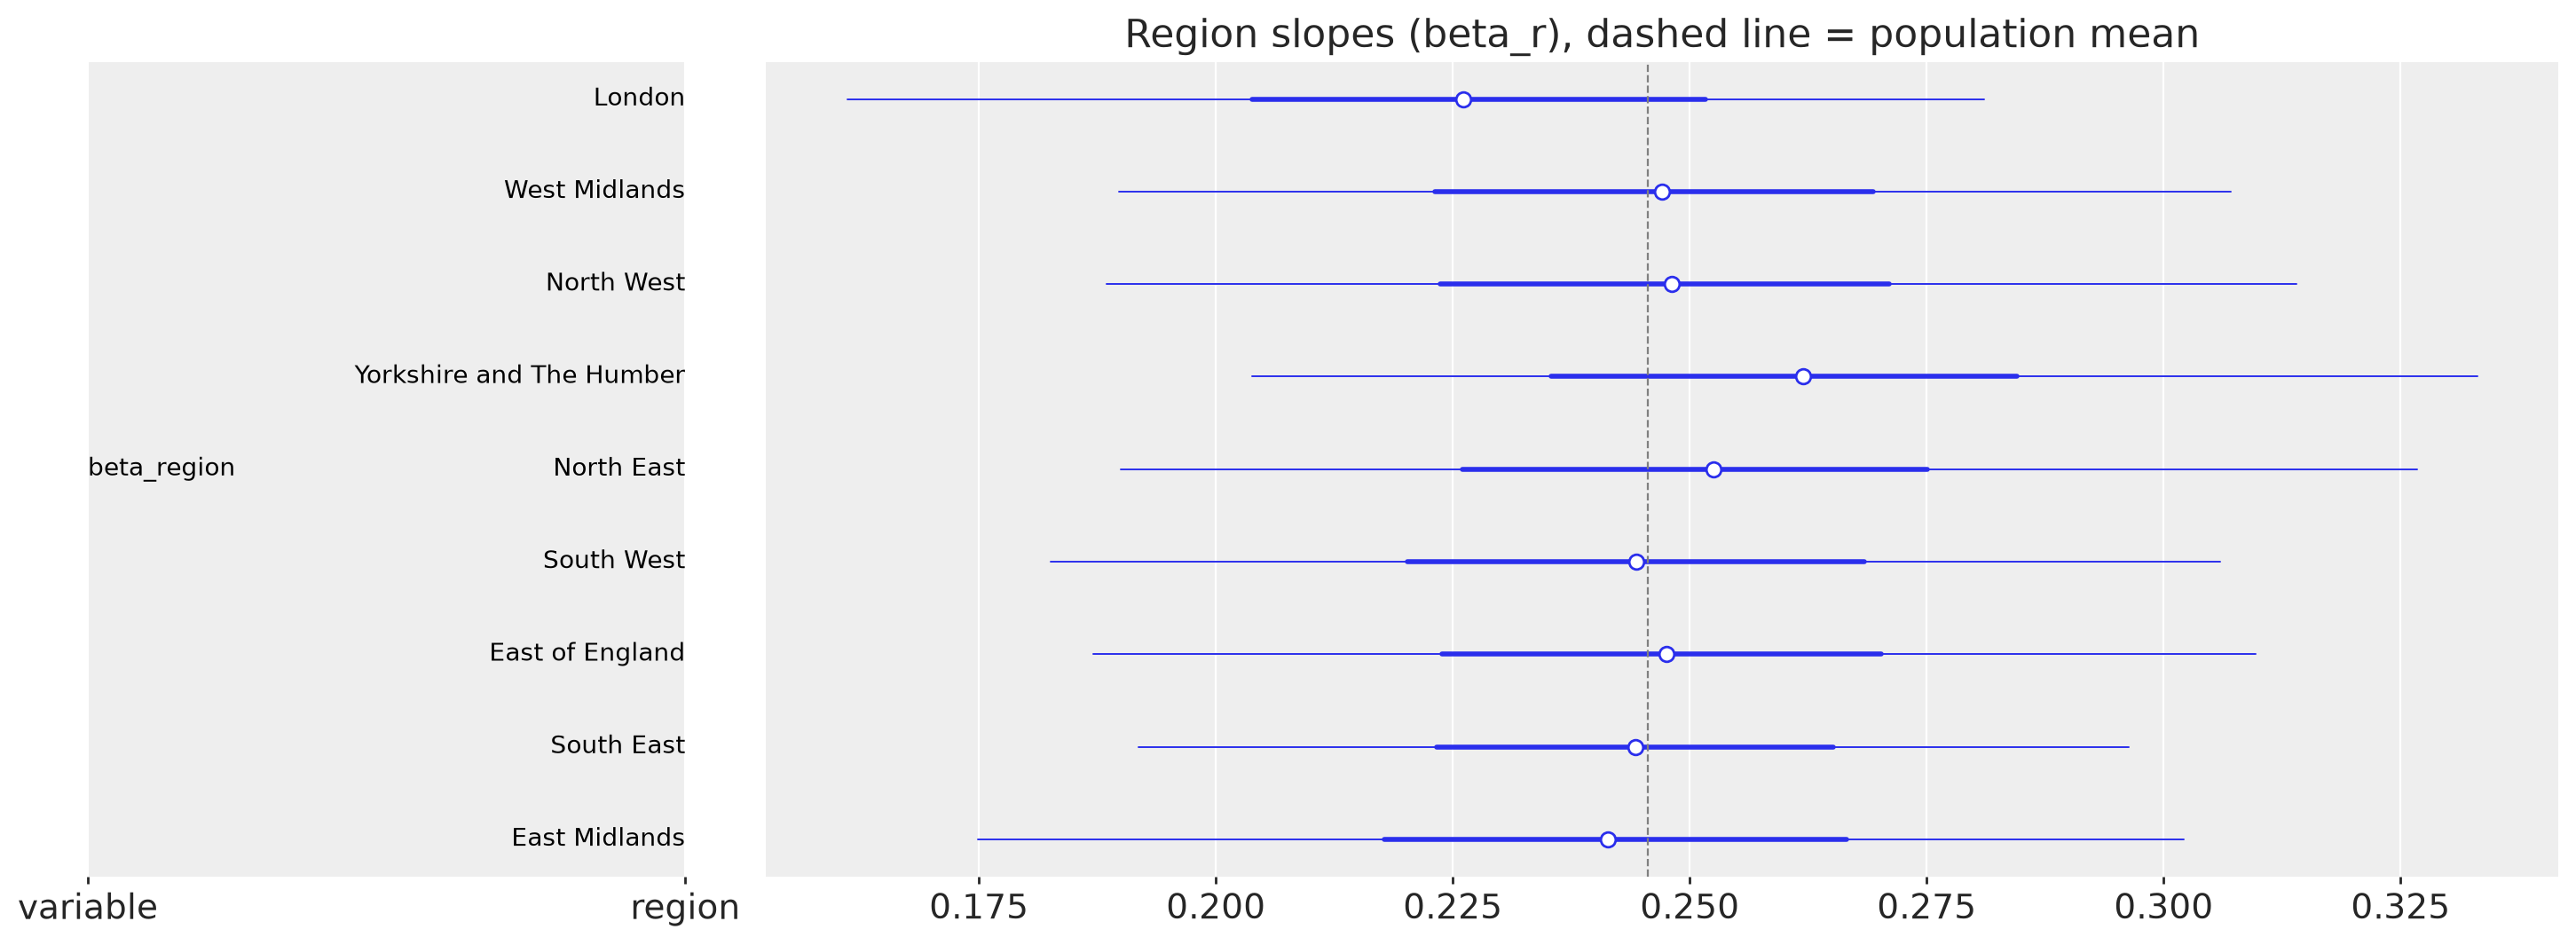

In [10]:
az.plot_forest(idata_region, var_names=["alpha_region"], combined=True)
plt.axvline(idata_region.posterior["mu_alpha"].to_numpy().mean(), color="grey", linewidth=0.8, linestyle="--")
plt.title("Region intercepts (alpha_r), dashed line = population mean")
plt.show()

az.plot_forest(idata_region, var_names=["beta_region"], combined=True)
plt.axvline(idata_region.posterior["mu_beta"].to_numpy().mean(), color="grey", linewidth=0.8, linestyle="--")
plt.title("Region slopes (beta_r), dashed line = population mean")
plt.show()

## Goodness of fit

Bayesian $R^2$ on the latent scale: the variance of the structural fit relative to the fit plus the residual variance $\tau_y^2$. (PSIS-LOO is unreliable for models with a latent parameter per school, as found in the Maths notebook, so we don't use it.)

R², base:   mean=0.172, sd=0.027
R², region: mean=0.189, sd=0.028
beta, base:        mean=0.254, sd=0.022
mu_beta, region:   mean=0.246, sd=0.029


/tmp/ipykernel_70788/1914195891.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


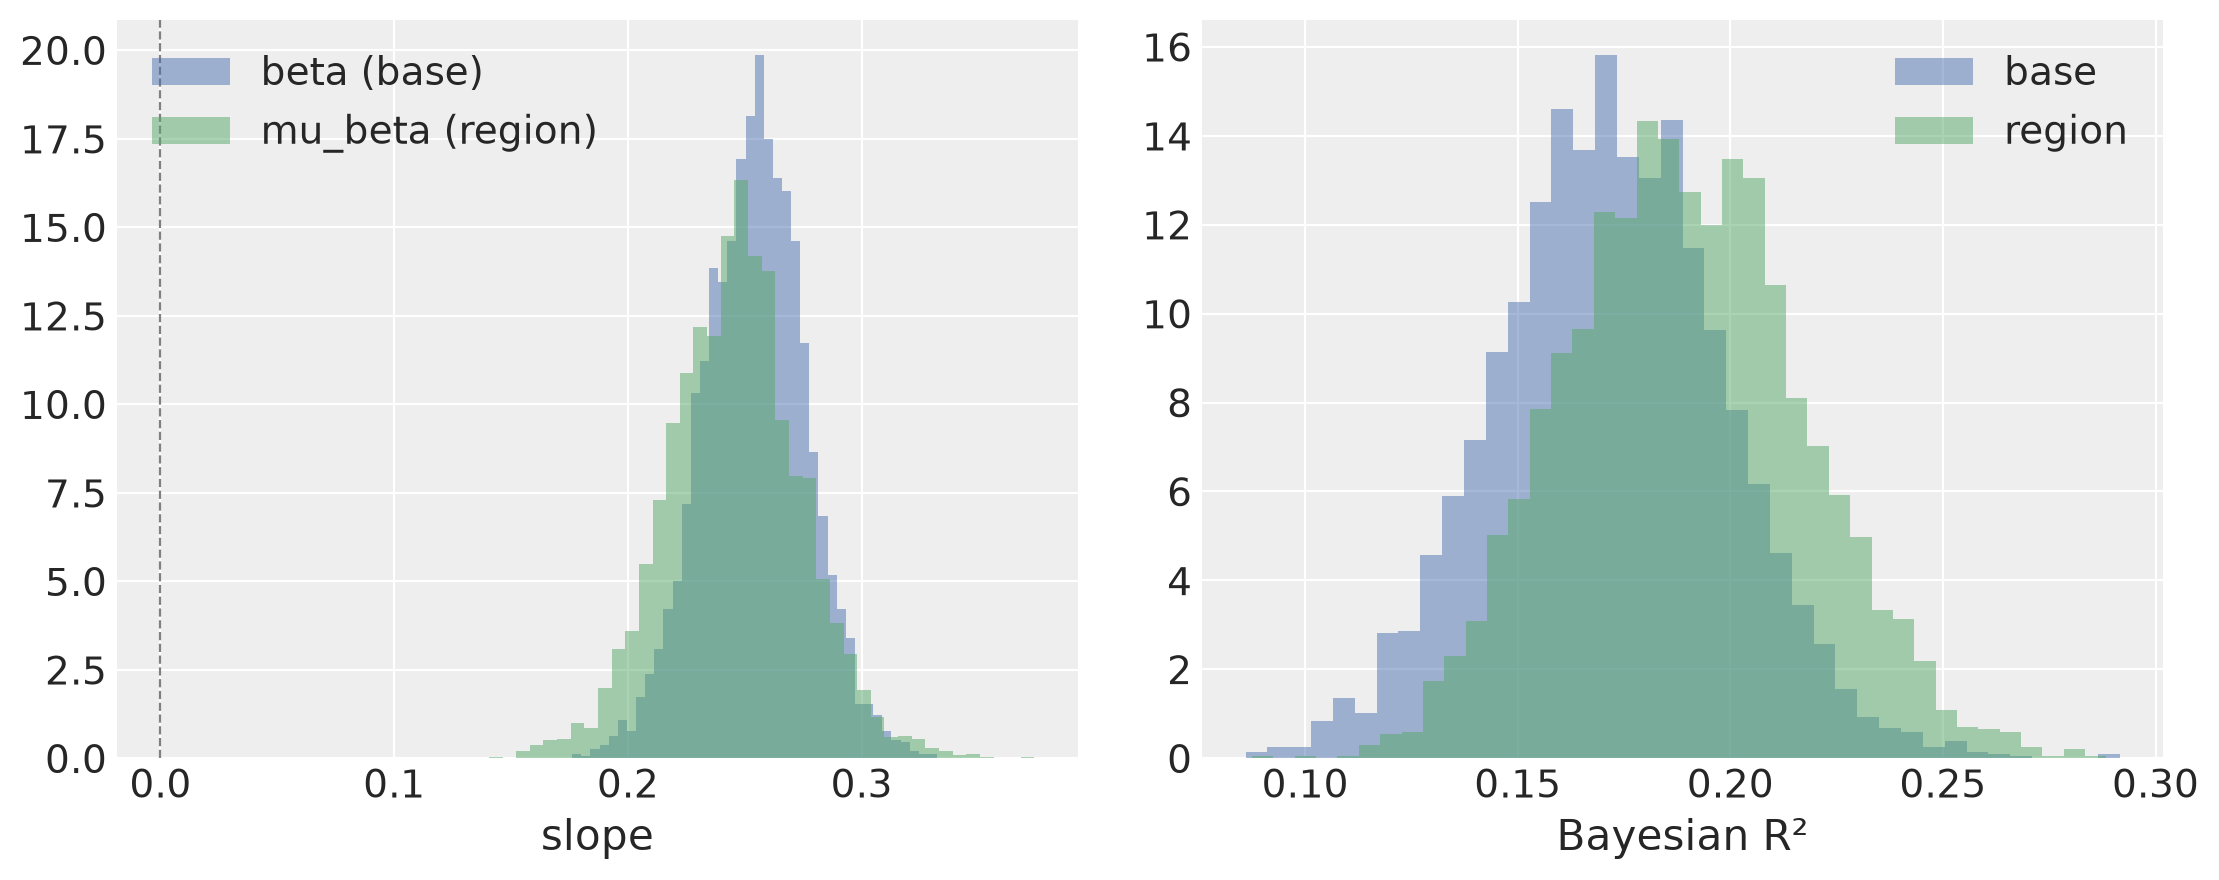

In [11]:
def bayes_r2(idata, regional):
    x_s = idata.posterior["x_true"].to_numpy()
    tau_s = idata.posterior["tau_y"].to_numpy()
    if regional:
        a = idata.posterior["alpha_region"].to_numpy()[..., region_idx]
        b = idata.posterior["beta_region"].to_numpy()[..., region_idx]
        y_hat = a + b * x_s
    else:
        y_hat = idata.posterior["alpha"].to_numpy()[..., None] + idata.posterior["beta"].to_numpy()[..., None] * x_s
    var_fit = y_hat.var(axis=-1)
    return (var_fit / (var_fit + tau_s**2)).ravel()

r2_base = bayes_r2(idata_base, regional=False)
r2_region = bayes_r2(idata_region, regional=True)
beta_base = idata_base.posterior["beta"].to_numpy().ravel()
mu_beta_region = idata_region.posterior["mu_beta"].to_numpy().ravel()

print(f"R², base:   mean={r2_base.mean():.3f}, sd={r2_base.std():.3f}")
print(f"R², region: mean={r2_region.mean():.3f}, sd={r2_region.std():.3f}")
print(f"beta, base:        mean={beta_base.mean():.3f}, sd={beta_base.std():.3f}")
print(f"mu_beta, region:   mean={mu_beta_region.mean():.3f}, sd={mu_beta_region.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(beta_base, bins=40, density=True, alpha=0.5, color="#4C72B0", label="beta (base)")
axes[0].hist(mu_beta_region, bins=40, density=True, alpha=0.5, color="#55A868", label="mu_beta (region)")
axes[0].axvline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("slope")
axes[0].legend()
axes[1].hist(r2_base, bins=40, density=True, alpha=0.5, color="#4C72B0", label="base")
axes[1].hist(r2_region, bins=40, density=True, alpha=0.5, color="#55A868", label="region")
axes[1].set_xlabel("Bayesian R²")
axes[1].legend()
plt.tight_layout()
plt.show()

### Residual vs. GCSE value-added

If the linear relationship is adequate, the binned mean residual should stay near zero across the range of GCSE VA.

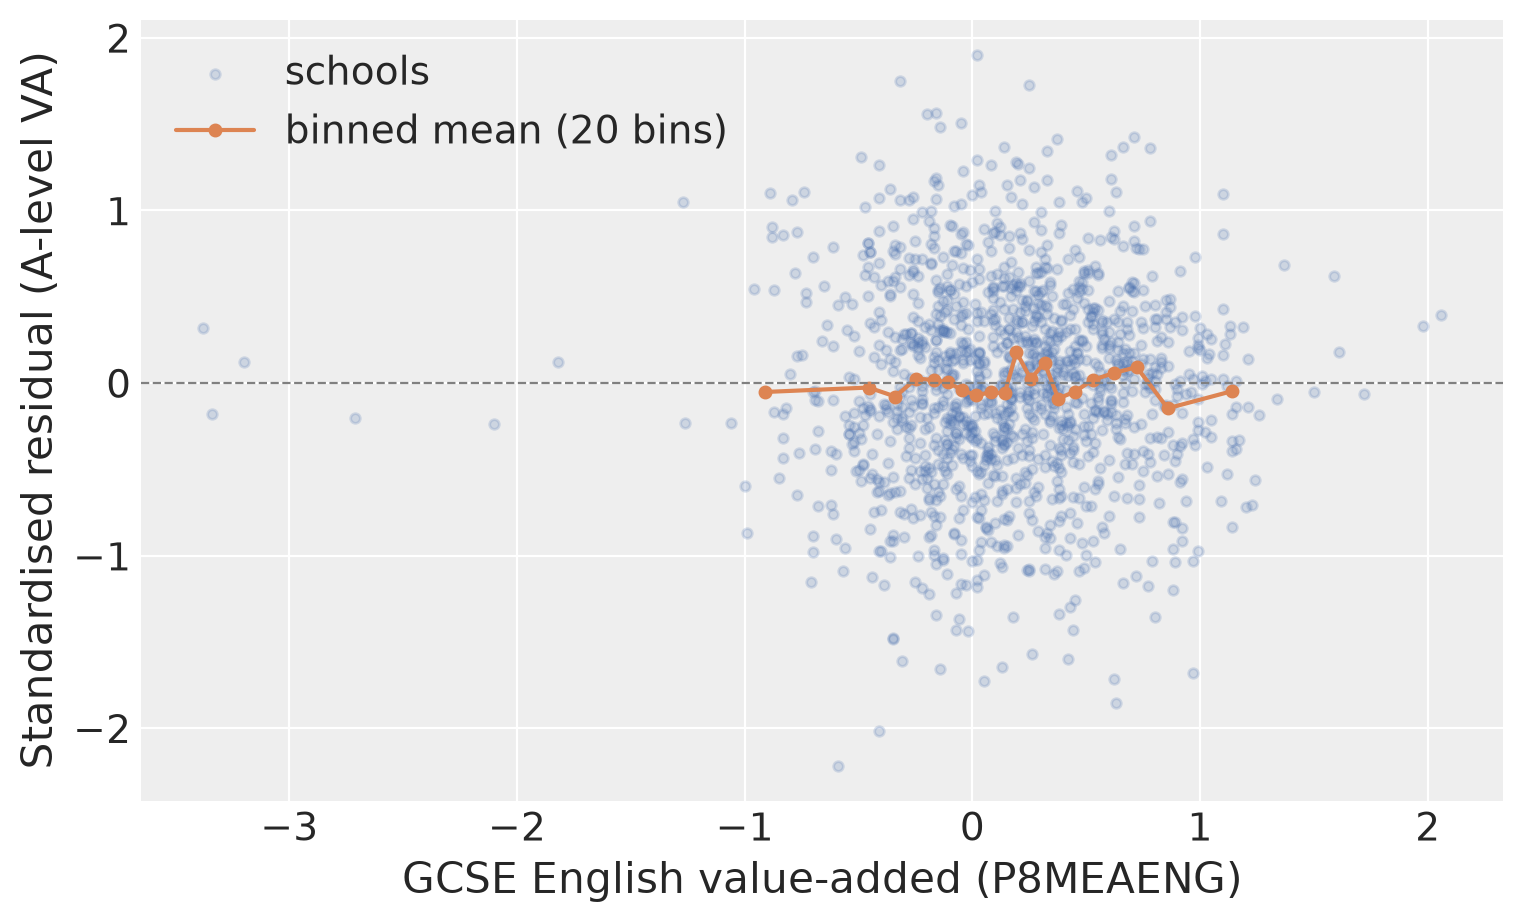

In [12]:
pred = idata_region.posterior_predictive["alevel_obs"].to_numpy().reshape(-1, n_schools)
df["std_resid"] = (alevel_obs - pred.mean(axis=0)) / pred.std(axis=0)

binned = df.groupby(pd.qcut(df["gcse_va"], 20), observed=True).agg(
    gcse_va=("gcse_va", "mean"), std_resid=("std_resid", "mean")
)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(df["gcse_va"], df["std_resid"], color="#4C72B0", alpha=0.2, s=12, label="schools")
ax.plot(binned["gcse_va"], binned["std_resid"], color="#DD8452", marker="o", markersize=4, linewidth=1.5, label="binned mean (20 bins)")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("GCSE English value-added (P8MEAENG)")
ax.set_ylabel("Standardised residual (A-level VA)")
ax.legend()
plt.show()

### Do the strongest GCSE schools "top out"?

Mean A-level English Literature VA by decile of GCSE English VA.

,mean_gcse_va,mean_alevel_va,n_schools
gcse_va,,,
1,-0.692748,-0.263740,131
2,-0.292205,-0.154646,127
3,-0.137090,-0.096567,134
4,-0.014341,-0.106202,129
5,0.111484,-0.079375,128
6,0.227419,0.043548,124
7,0.348321,0.019771,131
8,0.492171,0.041550,129
9,0.673333,0.141463,123


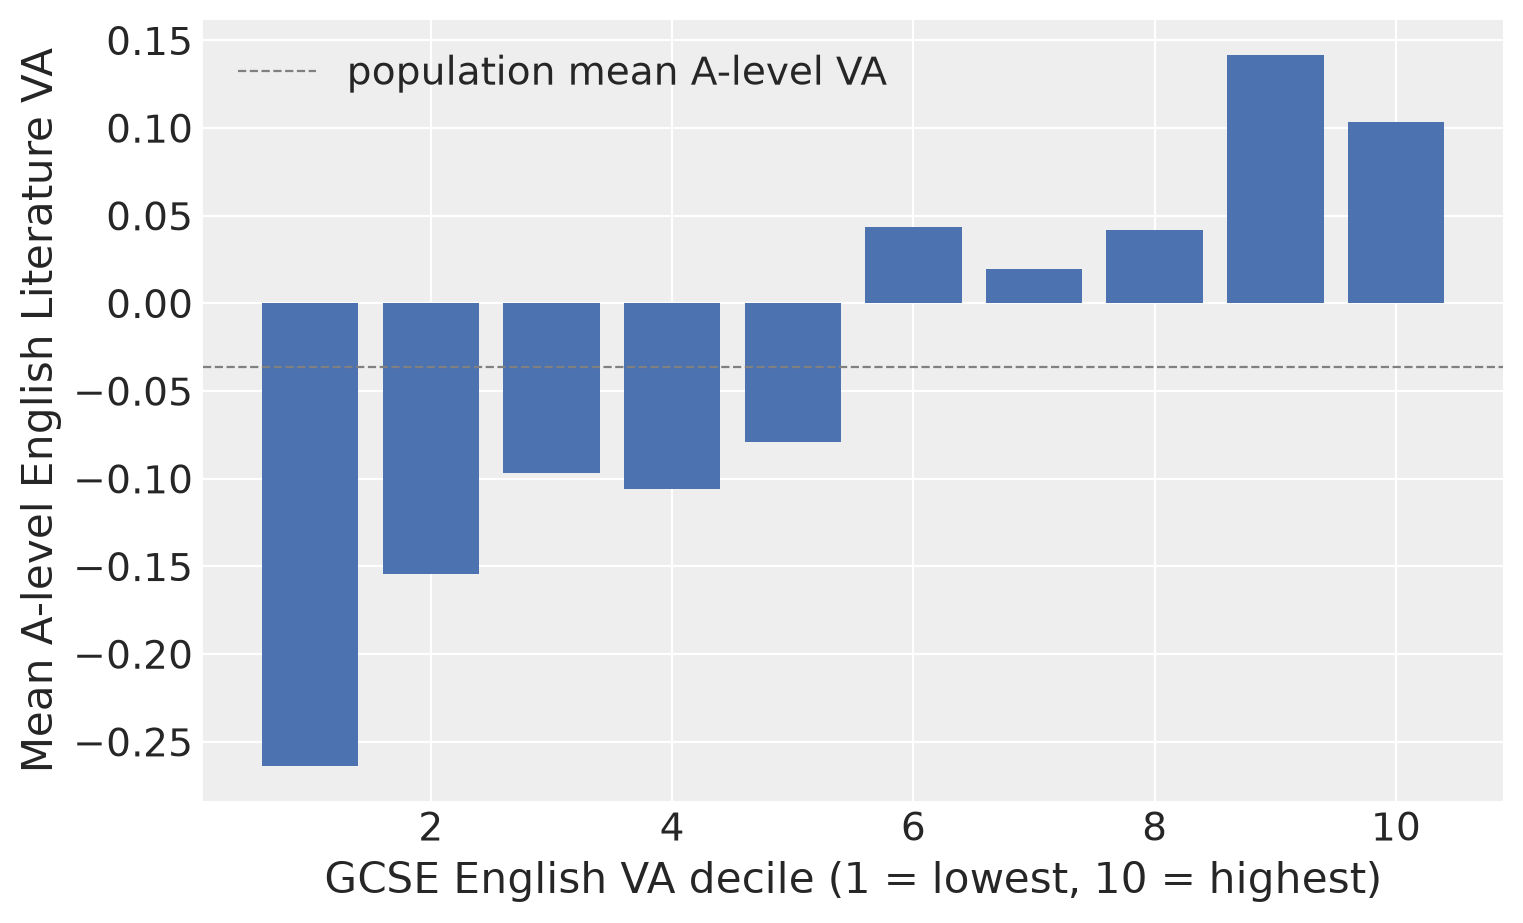

In [13]:
overall_mean = df["alevel_va"].mean()
decile_table = df.groupby(pd.qcut(df["gcse_va"], 10, labels=range(1, 11)), observed=True).agg(
    mean_gcse_va=("gcse_va", "mean"), mean_alevel_va=("alevel_va", "mean"), n_schools=("URN", "count")
)
display(decile_table)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(decile_table.index.astype(int), decile_table["mean_alevel_va"], color="#4C72B0")
ax.axhline(overall_mean, color="grey", linewidth=0.8, linestyle="--", label="population mean A-level VA")
ax.set_xlabel("GCSE English VA decile (1 = lowest, 10 = highest)")
ax.set_ylabel("Mean A-level English Literature VA")
ax.legend()
plt.show()

## Interpretation

- **GCSE English VA carries over positively to A-level English Literature VA**, and by roughly the same amount as in Maths: the base slope is 0.25 (89% interval 0.22–0.29) versus about 0.28 for Maths. As in Maths, it is far from 1:1.
- **The relationship is somewhat tighter than in Maths.** Bayesian R² is 0.17 (base) and 0.19 (with region), against about 0.11 and 0.13 for Maths, and the residual spread `tau_y` is smaller (0.27 versus 0.35). Most of the variation in a school's A-level English Literature VA is still unexplained by its GCSE English VA.
- **Regions differ modestly in baseline A-level VA** (`sigma_alpha` ≈ 0.05, interval 0.015–0.088, excludes zero) but **not meaningfully in the slope** (`sigma_beta` ≈ 0.03, interval starting at 0.004). `mu_beta` is essentially unchanged by adding the region level (0.246 versus 0.254), which is a robustness check on the slope. Region lifts R² only from 0.17 to 0.19.
- **No sign of nonlinearity or of topping out.** The binned residuals stay near zero across the GCSE VA range, and mean A-level VA rises across the deciles, from about -0.26 in decile 1 to about +0.10 in decile 10, so the strongest GCSE English schools still average above the population, not below.
- **Caveats.** A-level English Literature cohorts are small (median 13 entries, minimum 6), so each school's A-level VA is noisy; the measurement model accounts for this through the published intervals, but it also limits how much any single school's estimate can tell us. As in the Maths notebook, this is a single year of data, PSIS-LOO is not usable here, and in-sample predictive checks are optimistic for the best-measured schools, so we have not used them as evidence of calibration.